# Marigold horizontal leafs detector by using the sacred framework 

## 1. Imports and configuration

In [1]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "src" / "science_jubilee").is_dir():
        REPO_ROOT = parent
        break
else:
    raise RuntimeError("Could not locate the science_jubilee repository root")

SRC_ROOT = REPO_ROOT / "src"
for path in (SRC_ROOT, REPO_ROOT):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)


from science_jubilee.machine_session import MachineSession
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.filter_scene import run_filter_scene
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.target_horizontals import run_estimate_horizontal_targets
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.reconstruction import run_create_point_cloud
import imageio

DETECTOR_ROOT = SRC_ROOT / "science_jubilee/Vision/Marigold_Horizontal_leafs"
IMAGE_DIR = DETECTOR_ROOT / "input"
OUTPUT_DIR = DETECTOR_ROOT / "output/latest"
CONFIG_PATH = DETECTOR_ROOT / "config.yaml"
IMAGE_PATH = IMAGE_DIR / "latest.jpg"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
STEPS =1000
RUN_RECONSTRUCTION = False
TARGET_AUTO = False

def show(image, title=""):
    image_array = np.asarray(image)
    display_image = image_array if image_array.ndim == 3 else image_array
    plt.figure(figsize=(10, 7))
    plt.imshow(display_image, cmap="gray" if image_array.ndim == 2 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()
    
hardware=False


c:\Users\Justin\.conda\envs\marigold_env\lib\site-packages\sacred\dependencies.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 2. Capture the latest image (optional hardware step)

In [2]:
import time

if hardware:
    env = ".env.hardware"
else:
    env = ".env.mock"
    
session = MachineSession.from_env(env)
cam = session.camera
    
# move camera to imaging position and capture
X_DEPART, Y_DEPART, Z_DEPART = 130.0, 150.0, 320.0
if hardware == False:
    cam._image =  imageio.imread("input/test.png")
else:
    
    cam.move_to_get_image(X_DEPART, Y_DEPART, Z_DEPART)

image = cam.get_image()
image_out=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
cv2.imwrite(str(IMAGE_PATH), image_out)
print(f"Saved {IMAGE_PATH}")

Saved c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\input\latest.jpg


C:\Users\Justin\AppData\Local\Temp\ipykernel_9000\791972332.py:14: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  cam._image =  imageio.imread("input/test.png")


## 3. Load and inspect the image

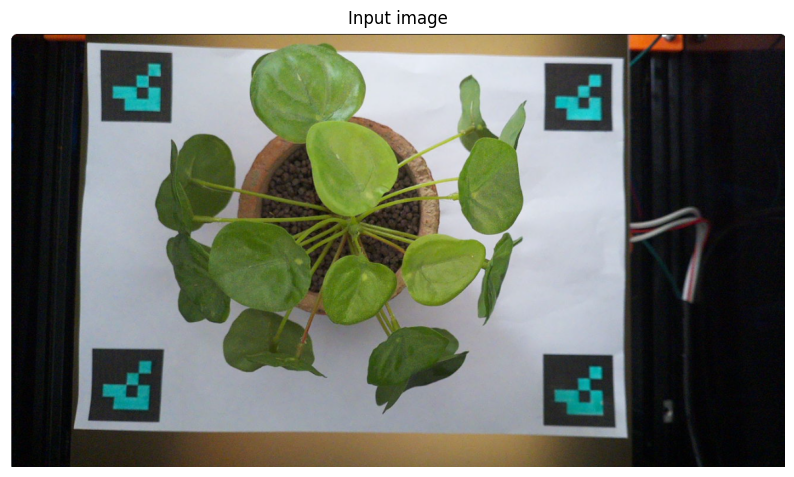

In [3]:
image2 = cv2.imread(str(IMAGE_PATH))

if image is None:
    raise FileNotFoundError(f"Unable to read {IMAGE_PATH}")
show(image, "Input image")


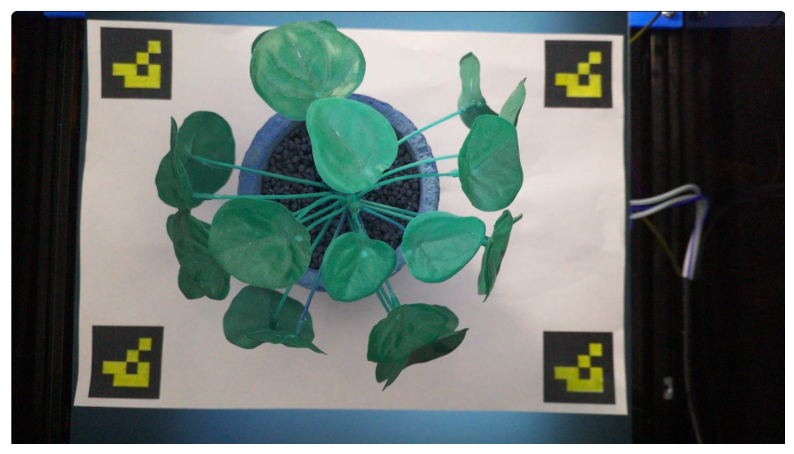

In [4]:
show(image2)

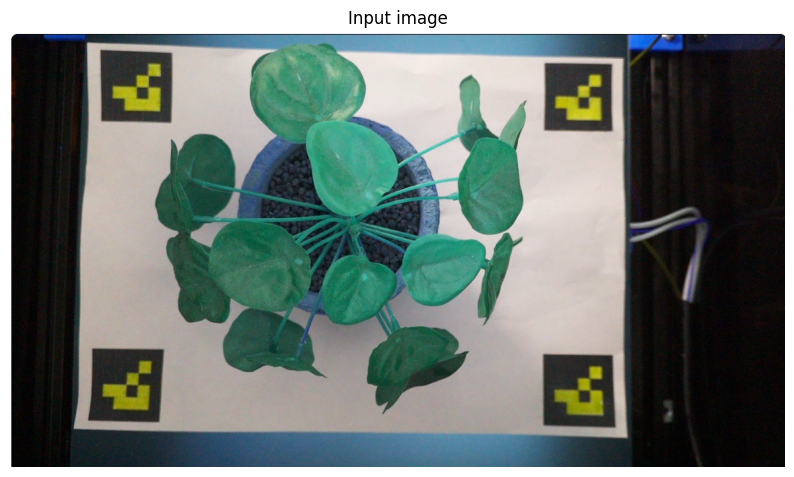

In [5]:
image = cv2.imread(str(IMAGE_PATH))
if image is None:
    raise FileNotFoundError(f"Unable to read {IMAGE_PATH}")
show(image, "Input image")

## 4. Segment the tray and plant

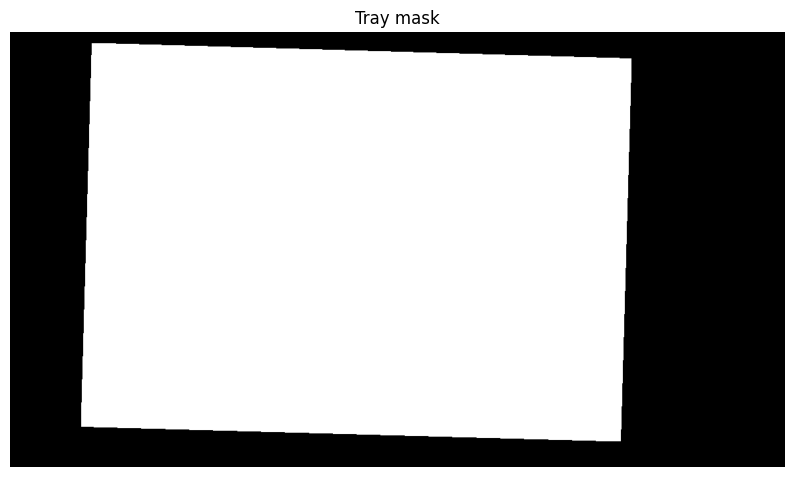

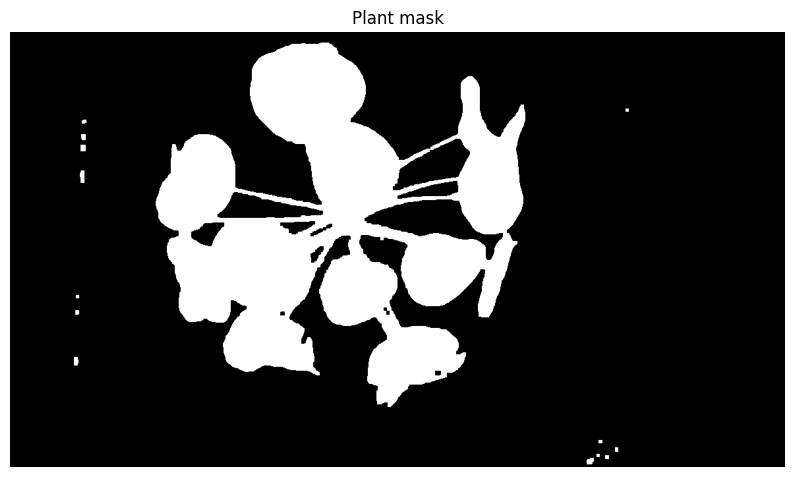

In [6]:
filtered = run_filter_scene(image=image)
show(filtered["tray_mask"], "Tray mask")
show(filtered["plant_mask"], "Plant mask")

## 5. Estimate depth and surface normals

## With Marigold

[+] Using device: cuda
[+] Loading Marigold depth and normal models...


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

...

Diffusion steps...:   0%|          | 0/1000 [00:00<?, ?it/s]

[+] Running normal estimation...


Marigold predictions...:   0%|          | 0/1 [00:00<?, ?it/s]

Diffusion steps...:   0%|          | 0/1000 [00:00<?, ?it/s]

[+] Depth saved to: c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\output\latest\latest_depth.npy
[+] Normals saved to: c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\output\latest\latest_normals.npy
Depth shape: (660, 1176)
Normals shape: (660, 1176, 3)


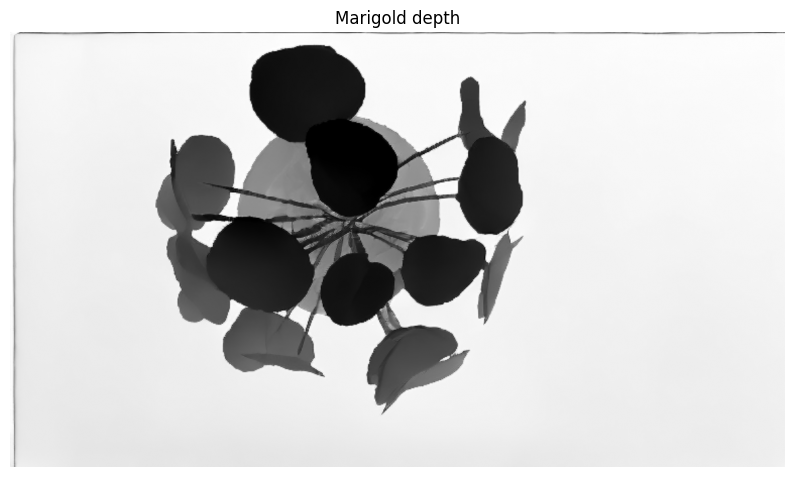

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


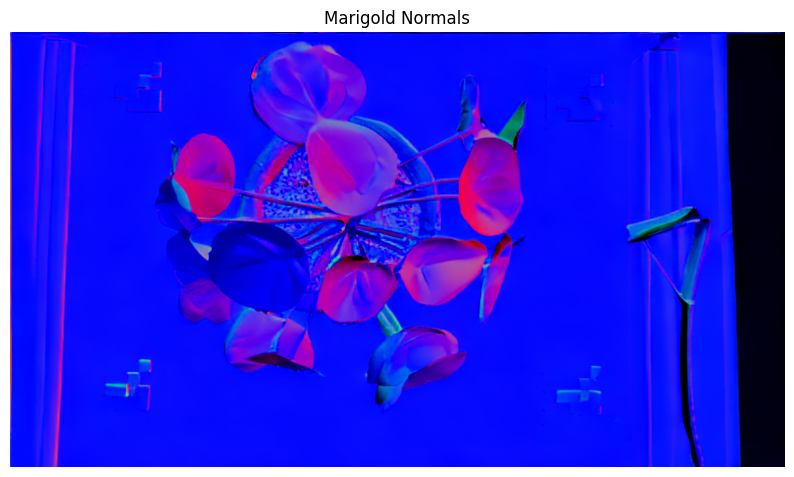

Range des profondeurs : min = 0.000, max = 1.000
Range des normales    : min = -1.000, max = 1.000


In [7]:
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.inference_marigold import run_infer_depths_and_normals

inference = run_infer_depths_and_normals(
    image=image,
    output_dir=str(OUTPUT_DIR),
    steps=STEPS,
    image_name=IMAGE_PATH.name,
)
depth_map = inference["depth"].squeeze()
normals = inference["normals"]

print("Depth shape:", depth_map.shape)
print("Normals shape:", normals.shape)
show(depth_map, "Marigold depth")
show(normals,"Marigold Normals" )


# Print du range de la profondeur
print(f"Range des profondeurs : min = {np.min(depth_map):.3f}, max = {np.max(depth_map):.3f}")

# Print du range des normales
print(f"Range des normales    : min = {np.min(normals):.3f}, max = {np.max(normals):.3f}")

In [8]:

# Print du range de la profondeur
print(f"Range des profondeurs : min = {np.min(depth_map):.3f}, max = {np.max(depth_map):.3f}")

# Print du range des normales
print(f"Range des normales    : min = {np.min(normals):.3f}, max = {np.max(normals):.3f}")

Range des profondeurs : min = 0.000, max = 1.000
Range des normales    : min = -1.000, max = 1.000


## With MoGe v3



Depth shape: (660, 1176)
Normals shape: (660, 1176, 3)


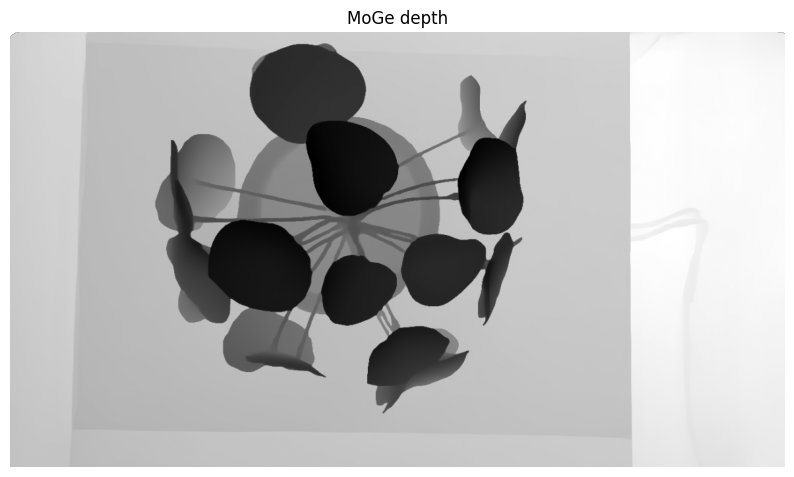

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9999999..0.99429953].


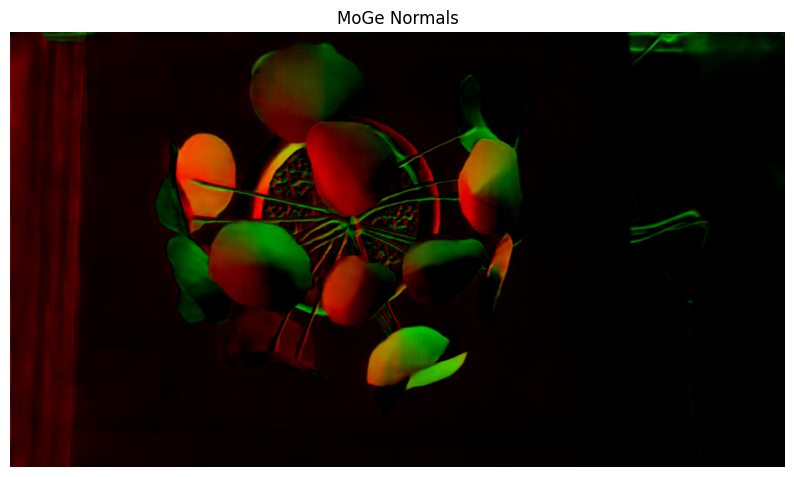

Range des profondeurs : min = 0.450, max = inf
Range des normales    : min = -1.000, max = 0.994


In [9]:
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.inference_MoGe import run_infer_depths_and_normals
inference = run_infer_depths_and_normals(
    image=image,
    output_dir=str(OUTPUT_DIR),
    image_name=IMAGE_PATH.name,
)
depth_map = inference["depth"]
normals = inference["normals"]
print("Depth shape:", depth_map.shape)
print("Normals shape:", normals.shape)
show(depth_map, "MoGe depth")
show(normals,"MoGe Normals" )

# Print du range de la profondeur
print(f"Range des profondeurs : min = {np.min(depth_map):.3f}, max = {np.max(depth_map):.3f}")

# Print du range des normales
print(f"Range des normales    : min = {np.min(normals):.3f}, max = {np.max(normals):.3f}")

## 6. Detect horizontal leaf targets


[DEBUG] START TARGET ESTIMATION PIPELINE
[+] Tray depth values: 331673 pixels, min=0.49, max=0.90
[1. Depth Scaling] Min: 159.94 mm | Max: 400.00 mm
[4. Clustering] 1er DBSCAN (Spatial 3D) sur 52672 points (eps=2mm)...
    -> Blobs spatiaux initiaux  : 20
    -> Blobs scindés par normal : 0
    -> Blobs cibles finaux      : 8

[+] Final valid targets detected: 8

Targets detected: 8


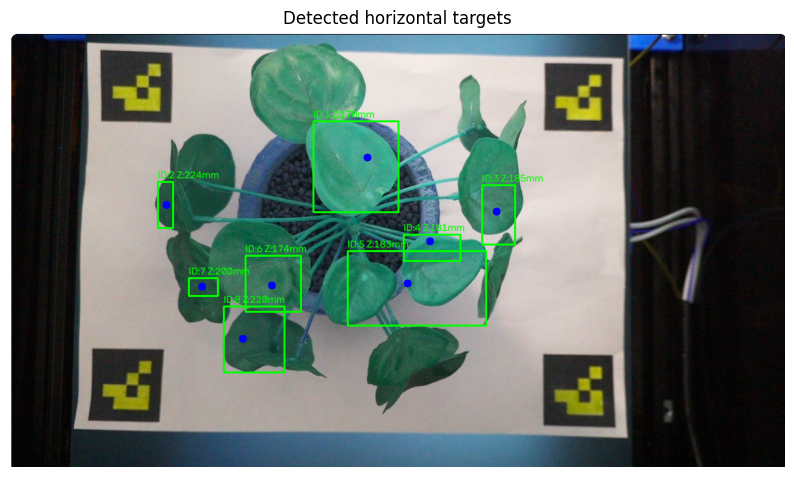

In [10]:
import yaml
targets_result = run_estimate_horizontal_targets(
    image=image,
    depth_map=depth_map,
    normals=normals,
    output_dir=str(OUTPUT_DIR),
    image_name=IMAGE_PATH.name,
    tray_z_mm=Z_DEPART,
    normal_threshold=0.95,
    min_area_px=500,
    max_area_px=10000,
    cluster_eps_mm=2,
    cluster_eps_normal=0.05,
    camera=cam,
    plant_height=None,
)
targets = targets_result["targets"]
overlay = targets_result["overlay"]
print(f"Targets detected: {len(targets)}")
show(overlay, "Detected horizontal targets")

## DEBUG ONLY: find best parameters for segentation and clustering of plants 


[DEBUG] START TARGET ESTIMATION PIPELINE
[1. Depth Scaling] Min: 159.94 mm | Max: 400.00 mm


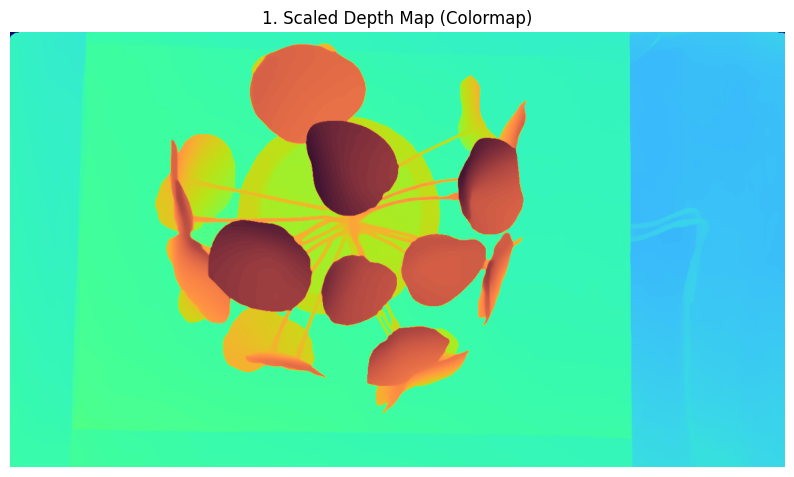

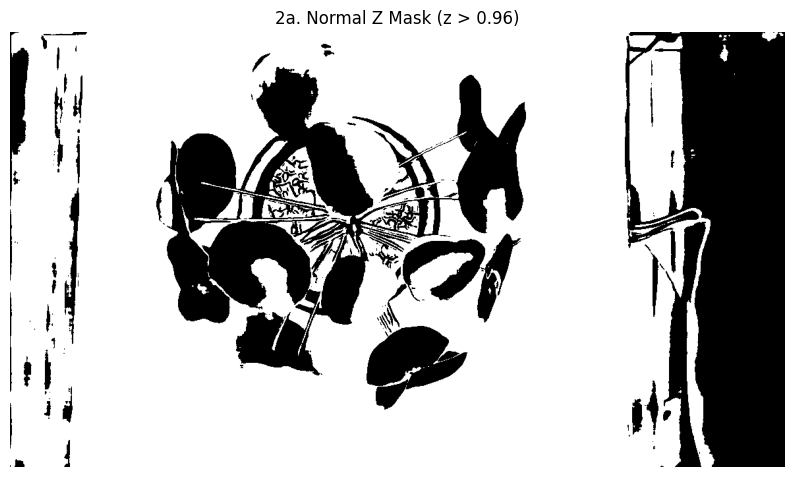

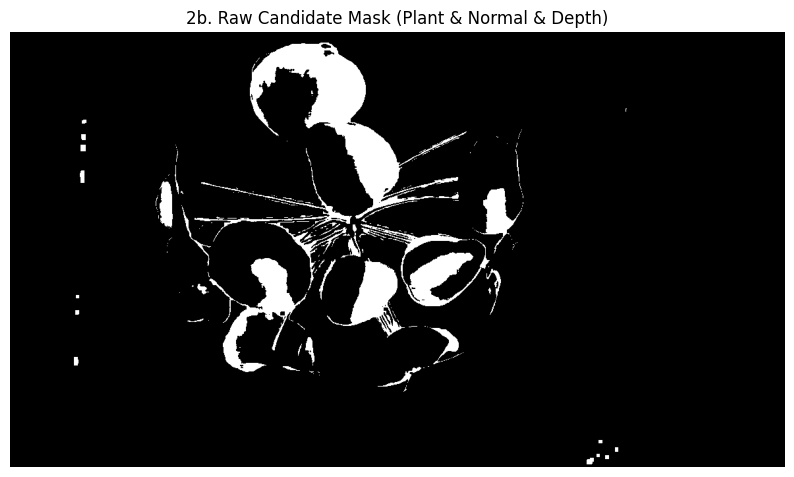

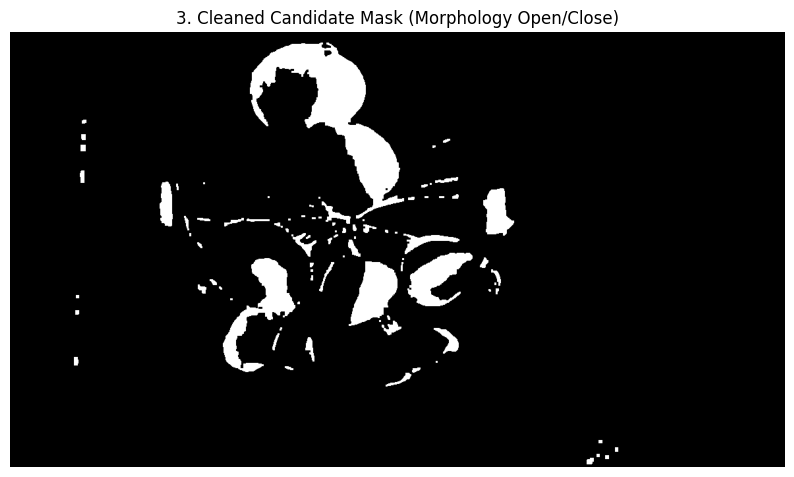

[4. Clustering] 1er DBSCAN (Spatial 3D) sur 43080 points (eps=2.0mm)...
    -> Blobs spatiaux initiaux  : 17
    -> Blobs scindés par normal : 0
    -> Blobs cibles finaux      : 9



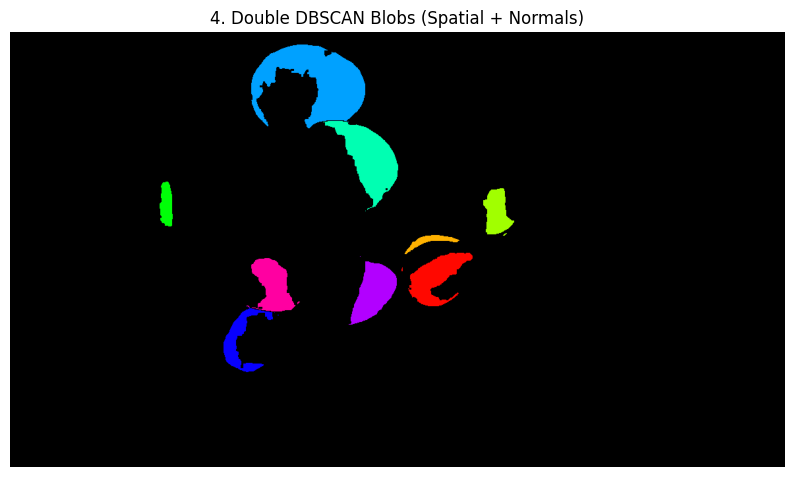

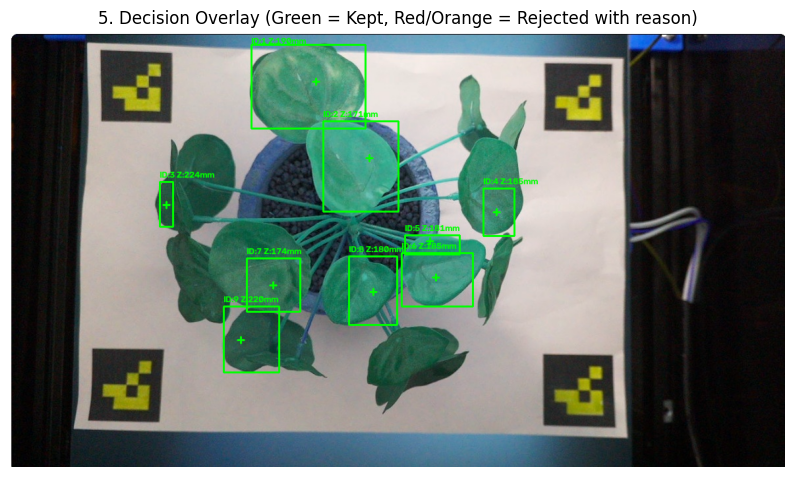


------------------------------ SUMMARY ------------------------------
Total initial blobs: 9
  - Dropped by 'area': 0
  - Dropped by 'extent': 0
  - Dropped by 'border': 0
  - Dropped by 'normal_vector': 0
  - Dropped by 'normal_conf': 0
  - Dropped by 'depth_std': 0
Final valid targets detected: 9



[{'id': 1,
  'pixel': [464, 75],
  'area_px': 11191,
  'bbox': [366, 19, 173, 127],
  'normal_confidence': array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ..., -0.9412501 ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ..., -0.9501989 ,
          -0.9432634 , -0.93863595],
         ...,
         [-0.9570654 , -0.9673241 , -0.9781142 , ..., -0.95216614,
          -0.9528085 , -0.95391154],
         [-0.9494391 , -0.9632972 , -0.97695756, ..., -0.9502578 ,
          -0.95036983, -0.9516734 ],
         [-0.9478505 , -0.96440583, -0.97707367, ..., -0.9490604 ,
          -0.94810057, -0.9489413 ]], dtype=float32),
  'xyz_mm': [-65.3885269165039, -59.280067443847656, 189.62948608398438]},
 {'id': 2,
  'pixel': [545, 191],
  'area_px': 6440,
  'bbox': [475, 135, 114, 137],
  'normal_confidence': array([[ 0.        ,  0.        ,  0.        , ...,  0.  

In [11]:
import cv2
import numpy as np
from skimage.segmentation import watershed
from skimage.filters import sobel
from sklearn.cluster import DBSCAN

tray_mask=filtered["tray_mask"]
plant_mask=filtered["plant_mask"]
config = {
    "camera": {
        "cx": 966.6098775996533,
        "cy": 533.9822650713481,
        "dist": [
            -0.01774652120816888,
            0.34775989653378375,
            -8.43022105306137e-05,
            0.0013051523863665852,
            -0.7666010432176091,
        ],
        "fx": 1453.20885729982,
        "fy": 1462.5327058475916,
    },
    "physical": {
        "tray_z_mm": 320.00,
        "plant_height_mm": 155.0,
        "tray_reference_mm": 320.00,
    },
    "filtering": {"min_area_px": 500,
  "min_normal_z": 0.96,
  "depth_consistency_max_std_mm": 1.4},
}
intrinsics=config["camera"]
def depth_to_camera_xyz(
    depth_map: np.ndarray, u: float, v: float, intrinsics: dict
) -> np.ndarray:
    # Thanks to the depth estimated by marigold we can compute the real world cordinates using camera pinhole model with iis calibrated camera parameters
    h, w = depth_map.shape[:2]
    u0 = int(np.clip(round(u), 0, w - 1))
    v0 = int(np.clip(round(v), 0, h - 1))
    z_value = np.asarray(depth_map[v0, u0]).reshape(-1)[0]
    z = float(z_value)

    K = np.array(
        [
            [intrinsics["fx"], 0, intrinsics["cx"]],
            [0, intrinsics["fy"], intrinsics["cy"]],
            [0, 0, 1],
        ],
        dtype=np.float32,
    )
    # Improvement of the model by including the distortion parameters given py the opencv calibration

    dist_np = np.array(intrinsics["dist"], dtype=np.float32)
    point_2d = np.array([[[u, v]]], dtype=np.float32)

    undistorted_pt = cv2.undistortPoints(point_2d, K, dist_np)
    x_norm = undistorted_pt[0, 0, 0]
    y_norm = undistorted_pt[0, 0, 1]

    x = x_norm * z
    y = y_norm * z
    return np.array([x, y, z], dtype=np.float32)

def return_targets():
    print("\n" + "=" * 50)
    print("[DEBUG] START TARGET ESTIMATION PIPELINE")
    print("=" * 50)

# -------------------------------------------------------------
    # 1. Depth Map Scaling & Visualization
    # -------------------------------------------------------------
    tray_depth_values = depth_map[tray_mask > 0]
    if tray_depth_values.size == 0 or np.isclose(np.max(tray_depth_values), 0.0):
        print("[!] Warning: Tray mask is empty or max depth is 0!")
        max_tray_depth = 1.0
    else:
        max_tray_depth = np.max(tray_depth_values)

    tray_z_mm = config["physical"]["tray_z_mm"]
    depth_mm = depth_map * (tray_z_mm / max_tray_depth)

    # Remplacement des infinis (et NaNs éventuels) par 400.0 mm
    depth_mm[np.isinf(depth_mm)] = 400.0
    depth_mm[np.isnan(depth_mm)] = 400.0

    print(
        f"[1. Depth Scaling] Min: {np.min(depth_mm):.2f} mm | Max: {np.max(depth_mm):.2f} mm"
    )

    # Visual 1: Scaled Depth Colormap
    depth_vis = cv2.normalize(
        depth_mm, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U
    )
    depth_colormap = cv2.applyColorMap(depth_vis, cv2.COLORMAP_TURBO)
    show(depth_colormap, "1. Scaled Depth Map (Colormap)")

    # -------------------------------------------------------------
    # 2. Mask Generation & Intermediate Visuals
    # -------------------------------------------------------------
    normal_z = normals[:, :, 2]
    normal_threshold = float(config.get("filtering", {}).get("min_normal_z", 0.94))

    normal_mask = (np.abs(normal_z)> normal_threshold).astype(np.uint8) * 255
    depth_valid_mask = (depth_mm > 0).astype(np.uint8) * 255

    candidate_mask_raw = cv2.bitwise_and(plant_mask, normal_mask)
    candidate_mask_raw = cv2.bitwise_and(candidate_mask_raw, depth_valid_mask)

    # Visual 2: Filtering intermediate masks
    show(normal_mask, f"2a. Normal Z Mask (z > {normal_threshold})")
    show(candidate_mask_raw, "2b. Raw Candidate Mask (Plant & Normal & Depth)")

    # -------------------------------------------------------------
    # 3. Morphology & Cleaning
    # -------------------------------------------------------------
    kernel = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(candidate_mask_raw, cv2.MORPH_OPEN, kernel)
    candidate_mask = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    show(candidate_mask, "3. Cleaned Candidate Mask (Morphology Open/Close)")

    intrinsics = {
            "fx": float(config["camera"]["fx"]),
            "fy": float(config["camera"]["fy"]),
            "cx": float(config["camera"]["cx"]),
            "cy": float(config["camera"]["cy"]),
            "dist": config["camera"]["dist"],
        }

    # -------------------------------------------------------------
    # 4. Double Clustering DBSCAN (Distance 3D puis Différence Normale Z)
    # -------------------------------------------------------------
    filtering_cfg = config.get("filtering", {})
    min_area_px = int(filtering_cfg.get("min_area_px", 500))
    max_area_px = int(filtering_cfg.get("max_area_px", 12000))
    
    # Paramètres de clustering (ajustables dans config.yaml)
    cluster_eps_mm = float(filtering_cfg.get("cluster_eps_mm", 2.0))       # Tolérance distance 3D (mm)
    cluster_eps_normal = float(filtering_cfg.get("cluster_eps_normal", 0.5)) # Tolérance diff normal_z (ex: 0.05)

    # --- Étape A : Vectorisation du calcul XYZ (Pin-hole model) ---
    h, w = depth_mm.shape
    u_grid, v_grid = np.meshgrid(np.arange(w), np.arange(h))
    
    points_2d = np.column_stack((u_grid.ravel(), v_grid.ravel())).astype(np.float32).reshape(-1, 1, 2)
    
    K = np.array([
        [intrinsics["fx"], 0, intrinsics["cx"]],
        [0, intrinsics["fy"], intrinsics["cy"]],
        [0, 0, 1]
    ], dtype=np.float32)
    dist_np = np.array(intrinsics["dist"], dtype=np.float32)

    undistorted_pts = cv2.undistortPoints(points_2d, K, dist_np)
    x_norm = undistorted_pts[:, 0, 0].reshape(h, w)
    y_norm = undistorted_pts[:, 0, 1].reshape(h, w)

    X = x_norm * depth_mm
    Y = y_norm * depth_mm
    XYZ_map = np.dstack((X, Y, depth_mm))

    # --- Étape B : Extraction des points candidats ---
    valid_mask = candidate_mask > 0
    valid_XYZ = XYZ_map[valid_mask]
    valid_normals_z = normal_z[valid_mask].reshape(-1, 1) # Format 2D requis pour DBSCAN
    valid_coords = np.column_stack(np.where(valid_mask))  # Format (y, x)

    print(f"[4. Clustering] 1er DBSCAN (Spatial 3D) sur {len(valid_XYZ)} points (eps={cluster_eps_mm}mm)...")
    
    # --- Étape C : Premier DBSCAN (Distance spatiale 3D) ---
    dbscan_spatial = DBSCAN(eps=cluster_eps_mm, min_samples=min_area_px // 4, n_jobs=-1)
    labels_spatial = dbscan_spatial.fit_predict(valid_XYZ)

    # Variables pour stocker les clusters finaux isolés
    final_labels_img = np.zeros((h, w), dtype=np.int32)
    current_label_id = 1
    split_by_normal_count = 0

    unique_spatial_labels = np.unique(labels_spatial)

    # --- Étape D : Deuxième DBSCAN (Orientation normal_z) sur chaque sous-groupe ---
    for sp_lbl in unique_spatial_labels:
        if sp_lbl == -1: 
            continue # Ignorer le bruit
            
        # Index des points appartenant à ce cluster spatial
        idx_cluster = np.where(labels_spatial == sp_lbl)[0]
        
        # S'il y a très peu de points, inutile de relancer un DBSCAN
        if len(idx_cluster) < min_area_px:
            continue
            
        # Récupération des valeurs normal_z du cluster
        cluster_normals = valid_normals_z[idx_cluster]
        
        # Second DBSCAN basé uniquement sur la similarité de l'orientation (normal_z)
        dbscan_norm = DBSCAN(eps=cluster_eps_normal, min_samples=min_area_px // 8, n_jobs=-1)
        labels_norm = dbscan_norm.fit_predict(cluster_normals)
        
        unique_norm_labels = np.unique(labels_norm)
        if len(unique_norm_labels) > 2: # Plus d'un groupe valide détecté (hors bruit -1)
            split_by_normal_count += 1
            
        # --- Étape E : Filtrage final et assignation sur l'image 2D ---
        for n_lbl in unique_norm_labels:
            if n_lbl == -1:
                continue
                
            idx_sub_cluster = idx_cluster[labels_norm == n_lbl]
            area = len(idx_sub_cluster)
            
            if min_area_px <= area <= max_area_px:
                y_c = valid_coords[idx_sub_cluster, 0]
                x_c = valid_coords[idx_sub_cluster, 1]
                final_labels_img[y_c, x_c] = current_label_id
                current_label_id += 1

    # --- Étape F : Construction des stats OpenCV manuellement ---
    # Cette étape remplace cv2.connectedComponentsWithStats pour empêcher
    # la refusion de 2 feuilles qui se touchent en 2D mais ont été séparées par DBSCAN.
    num_labels = current_label_id
    labels = final_labels_img
    stats = np.zeros((num_labels, 5), dtype=np.int32)
    centroids = np.zeros((num_labels, 2), dtype=np.float64)

    for i in range(1, num_labels):
        y_idx, x_idx = np.where(labels == i)
        stats[i, cv2.CC_STAT_LEFT] = x_idx.min()
        stats[i, cv2.CC_STAT_TOP] = y_idx.min()
        stats[i, cv2.CC_STAT_WIDTH] = x_idx.max() - x_idx.min() + 1
        stats[i, cv2.CC_STAT_HEIGHT] = y_idx.max() - y_idx.min() + 1
        stats[i, cv2.CC_STAT_AREA] = len(x_idx)
        centroids[i, 0] = x_idx.mean()
        centroids[i, 1] = y_idx.mean()

    total_blobs = num_labels - 1
    
    print(f"    -> Blobs spatiaux initiaux  : {len(unique_spatial_labels) - 1}")
    print(f"    -> Blobs scindés par normal : {split_by_normal_count}")
    print(f"    -> Blobs cibles finaux      : {total_blobs}\n")

    # Visual 4: Colored DBSCAN Blobs
    if num_labels > 1:
        label_hue = np.uint8(179 * labels / np.max(labels))
        blank_ch = 255 * np.ones_like(label_hue)
        labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
        labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)
        labeled_img[labels == 0] = 0
        show(labeled_img, "4. Double DBSCAN Blobs (Spatial + Normals)")
    # -------------------------------------------------------------
    # 5. Filtering Criteria & Debug Overlay
    # -------------------------------------------------------------
    intrinsics = {
        "fx": float(config["camera"]["fx"]),
        "fy": float(config["camera"]["fy"]),
        "cx": float(config["camera"]["cx"]),
        "cy": float(config["camera"]["cy"]),
        "dist": config["camera"]["dist"],
    }
    filtering_cfg = config.get("filtering", {})
    min_area_px = int(filtering_cfg.get("min_area_px",500))

    targets = []
    rejection_stats = {
        "area": 0,
        "extent": 0,
        "border": 0,
        "normal_vector": 0,
        "normal_conf": 0,
        "depth_std": 0,
    }

    # Prepare visual overlay (RGB copy)
    debug_overlay = image.copy()
    if len(debug_overlay.shape) == 2 or debug_overlay.shape[2] == 1:
        debug_overlay = cv2.cvtColor(debug_overlay, cv2.COLOR_GRAY2BGR)

    for label_idx in range(1, num_labels):
        area = int(stats[label_idx, cv2.CC_STAT_AREA])
        left = int(stats[label_idx, cv2.CC_STAT_LEFT])
        top = int(stats[label_idx, cv2.CC_STAT_TOP])
        width = int(stats[label_idx, cv2.CC_STAT_WIDTH])
        height = int(stats[label_idx, cv2.CC_STAT_HEIGHT])
        cx, cy = centroids[label_idx]
        u, v = int(round(cx)), int(round(cy))

        # Check 1: Area
        if area < min_area_px:
            print(f"blob with area {area} rejected because less than {min_area_px}")
            rejection_stats["area"] += 1
            cv2.rectangle(
                debug_overlay,
                (left, top),
                (left + width, top + height),
                (0, 0, 255),
                1,
            )
            cv2.putText(
                debug_overlay,
                f"#{label_idx}: Area",
                (left, max(15, top - 4)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (0, 0, 255),
                1,
            )
            continue
        xyz = depth_to_camera_xyz(depth_mm, u, v, intrinsics)
       

        # ACCEPTED TARGET -> Green bounding box and centroid marker
        cv2.rectangle(
            debug_overlay,
            (left, top),
            (left + width, top + height),
            (0, 255, 0),
            2,
        )
        cv2.drawMarker(
            debug_overlay,
            (u, v),
            (0, 255, 0),
            markerType=cv2.MARKER_CROSS,
            markerSize=10,
            thickness=2,
        )
        cv2.putText(
            debug_overlay,
            f"ID:{label_idx} Z:{xyz[2]:.0f}mm",
            (left, max(18, top - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (0, 255, 0),
            2,
        )

        targets.append(
            {
                "id": label_idx,
                "pixel": [int(u), int(v)],
                "area_px": area,
                "bbox": [left, top, width, height],
                "normal_confidence": normal_z,
                "xyz_mm": [float(xyz[0]), float(xyz[1]), float(xyz[2])],
            }
        )

    # Visual 5: Final diagnostic overlay
    show(
        debug_overlay,
        "5. Decision Overlay (Green = Kept, Red/Orange = Rejected with reason)",
    )

    print("\n" + "-" * 30 + " SUMMARY " + "-" * 30)
    print(f"Total initial blobs: {total_blobs}")
    for reason, count in rejection_stats.items():
        print(f"  - Dropped by '{reason}': {count}")
    print(f"Final valid targets detected: {len(targets)}")
    print("=" * 69 + "\n")

    return targets
return_targets()

## 7. Select a target

In [12]:
if not targets:
    raise RuntimeError("No horizontal targets detected; inspect the masks or rerun inference.")
if TARGET_AUTO:
    target = max(targets, key=lambda item: -item["xyz_mm"][2])
else:
    for index, candidate in enumerate(targets):
        print(index, candidate)
        print("Select a target among the above list")

0 {'id': 1, 'pixel': [542, 190], 'area_px': 7075, 'bbox': [460, 135, 129, 138], 'normal_confidence': -0.9819774031639099, 'depth_std_mm': 1.744727611541748, 'xyz_mm': [-48.3937873840332, -40.52982711791992, 170.44052124023438], 'normal': [0.18746154010295868, 0.024052027612924576, -0.9819774031639099]}
Select a target among the above list
1 {'id': 2, 'pixel': [237, 262], 'area_px': 1205, 'bbox': [224, 227, 23, 70], 'normal_confidence': -0.9839425086975098, 'depth_std_mm': 1.3979586362838745, 'xyz_mm': [-109.03199768066406, -42.07282638549805, 224.14588928222656], 'normal': [-0.14478132128715515, 0.1043812483549118, -0.9839425086975098]}
Select a target among the above list
2 {'id': 3, 'pixel': [738, 272], 'area_px': 2519, 'bbox': [716, 232, 50, 90], 'normal_confidence': -0.9955623149871826, 'depth_std_mm': 1.1193420886993408, 'xyz_mm': [-28.152416229248047, -34.000728607177734, 185.01034545898438], 'normal': [0.07382673770189285, -0.058355070650577545, -0.9955623149871826]}
Select a ta

In [13]:
target = targets[2]  #your target choice
print("Selected target:", target)
print(target['xyz_mm'])


Selected target: {'id': 3, 'pixel': [738, 272], 'area_px': 2519, 'bbox': [716, 232, 50, 90], 'normal_confidence': -0.9955623149871826, 'depth_std_mm': 1.1193420886993408, 'xyz_mm': [-28.152416229248047, -34.000728607177734, 185.01034545898438], 'normal': [0.07382673770189285, -0.058355070650577545, -0.9955623149871826]}
[-28.152416229248047, -34.000728607177734, 185.01034545898438]


## 8. Move into the target

In [14]:
supplementary_offset_xyz = [
        -10.0,
        15.0,
        0,
    ]
# On se déplace vers le target en gardant la même hauteur
if hardware:    
    nav= session.free_navigator
    nav.move_to(
        x=X_DEPART + target["xyz_mm"][0] + cam.offset[0]+supplementary_offset_xyz[0],
        y=Y_DEPART - target["xyz_mm"][1] + cam.offset[1]+ supplementary_offset_xyz[1],
        speed=3000.0,
        wait=True,
    )
    nav.move_to(
        z=Z_DEPART + cam.offset[2] - target["xyz_mm"][2] - 5+supplementary_offset_xyz[2], speed=1000.0, wait=True
    )

## 8. Create Point cloud from depth

In [ ]:
import open3d as o3d
results = run_create_point_cloud(
    image=image,
    depth_map=depth_map,
    camera=cam,
    alpha=0.005,           # Paramètre de l'Alpha Shape (plus petit = plus fin/troué)
    decimate_ratio=0.5,    # Réduit le nombre de triangles de 50%
    output_dir="./output_3d",
    image_name="test_plant.jpg"
)

# 4. Extraction du maillage
mesh = results["mesh"]

# 5. Visualisation interactive avec Open3D
print("[Visualisation] Ouverture de la fenêtre Open3D... (Fermez la fenêtre pour rendre la main au script)")

# On recalcule les normales pour que la lumière s'affiche correctement sur le mesh
mesh.compute_vertex_normals()

o3d.visualization.draw_geometries(
    [mesh],
    window_name="Reconstruction 3D - Maillage des feuilles",
    width=1280,
    height=720,
    mesh_show_wireframe=False,   
    mesh_show_back_face=True     
)

MissingConfigError: run_create_point_cloud is missing value(s): ['camera']